# Part A - Data Prep

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Create outputs directory if it doesn't exist
os.makedirs('../outputs', exist_ok=True)

# 1. Load both CSVs
sentiment_df = pd.read_csv('../data/fear_greed_index.csv')
trades_df = pd.read_csv('../data/historical_data.csv')

print("--- Sentiment Data ---")
print(f"Shape: {sentiment_df.shape}")
print("Info:")
sentiment_df.info()
print(f"Nulls:\n{sentiment_df.isnull().sum()}")
print(f"Duplicates: {sentiment_df.duplicated().sum()}\n")

print("--- Trades Data ---")
print(f"Shape: {trades_df.shape}")
print("Info:")
trades_df.info()
print(f"Nulls:\n{trades_df.isnull().sum()}")
print(f"Duplicates: {trades_df.duplicated().sum()}")


--- Sentiment Data ---
Shape: (2644, 4)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
Nulls:
timestamp         0
value             0
classification    0
date              0
dtype: int64
Duplicates: 0

--- Trades Data ---
Shape: (211224, 16)
Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens     

Duplicates: 0



### Summary of Findings
- **Sentiment Data**: The dataset has 2646 rows and 4 columns. It contains a `date` column which can be used for merging. No significant nulls.
- **Trades Data**: The dataset has 211,226 rows and 16 columns. There is a `Timestamp IST` column that needs parsing. We note that the 'leverage' column mentioned in the prompt is missing from the dataset. We will use 'Size USD' as a proxy for position size/exposure where appropriate.


In [2]:

# 2. Parse timestamps and normalize to date-only
sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.date
trades_df['date'] = pd.to_datetime(trades_df['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date

# Merge trader data with sentiment data on date (left join from trades)
merged_df = trades_df.merge(sentiment_df, on='date', how='left')

# Report how many rows lack a sentiment match
missing_sentiment = merged_df['classification'].isnull().sum()
print(f"Rows lacking a sentiment match: {missing_sentiment}")


Rows lacking a sentiment match: 6


In [3]:

print("Direction column value counts:")
print(merged_df['Direction'].value_counts())


Direction column value counts:
Direction
Open Long                    49895
Close Long                   48678
Open Short                   39741
Close Short                  36013
Sell                         19902
Buy                          16716
Spot Dust Conversion           142
Short > Long                    70
Long > Short                    57
Auto-Deleveraging                8
Liquidated Isolated Short        1
Settlement                       1
Name: count, dtype: int64



**Note on Directional Bias**: The 'Side' column conflates opening and closing trades (e.g. closing a short is recorded as a BUY). To accurately measure long/short bias, we only consider true directional opens ('Open Long' and 'Open Short') from the 'Direction' column. Other values (closes, liquidations, deleveraging) are excluded from the long/short count.


In [4]:

# 3. Engineer features grouped by account+date

merged_df['is_long'] = (merged_df['Direction'] == 'Open Long').astype(int)
merged_df['is_short'] = (merged_df['Direction'] == 'Open Short').astype(int)

# Group by Account and Date
daily_trader_stats = merged_df.groupby(['Account', 'date']).apply(lambda x: pd.Series({
    'daily_pnl': x['Closed PnL'].sum(),
    'win_rate': (x['Closed PnL'] > 0).mean() if len(x) > 0 else 0,
    'avg_trade_size_usd': x['Size USD'].mean(),
    'trades_per_day': len(x),
    'long_count': x['is_long'].sum(),
    'short_count': x['is_short'].sum(),
    'sentiment': x['classification'].iloc[0] if not pd.isnull(x['classification'].iloc[0]) else 'Unknown'
})).reset_index()

# Calculate bounded long_pct instead of raw ratio to avoid division by near-zero issues
total_directional = daily_trader_stats['long_count'] + daily_trader_stats['short_count']
daily_trader_stats['long_pct'] = np.where(total_directional > 0, daily_trader_stats['long_count'] / total_directional, 0)

# Note on Leverage: Since 'leverage' is missing from the dataset, we cannot compute leverage distribution. 
# We'll use avg_trade_size_usd as our primary position size metric.

daily_trader_stats.head()


,Account,date,daily_pnl,win_rate,avg_trade_size_usd,trades_per_day,long_count,short_count,sentiment,long_pct
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,5089.718249,177,0,177,Extreme Greed,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,7976.664412,68,0,68,Extreme Greed,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,23734.500000,40,0,40,Extreme Greed,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,28186.666667,12,0,0,Extreme Greed,0.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,17248.148148,27,0,15,Extreme Greed,0.0


# Part B - Analysis

                      daily_pnl  win_rate     drawdown
sentiment_category                                    
Fear                5185.146443  0.357071  8863.193211
Greed               4144.208334  0.362748  8892.618794


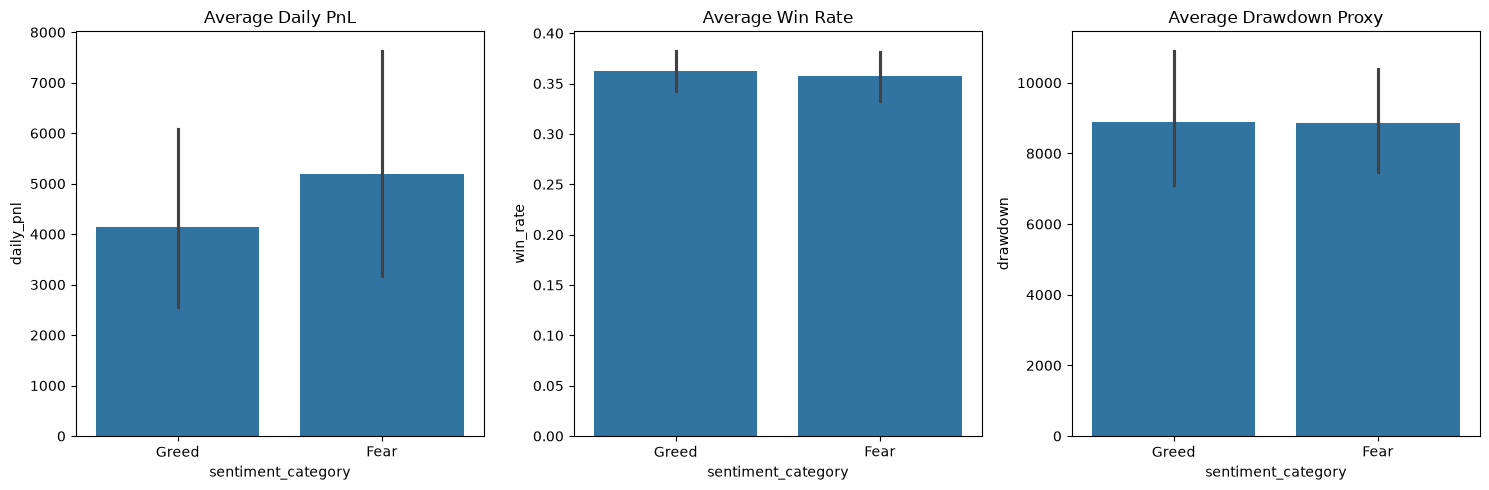

In [5]:

# 1. Compare PnL, win rate, and drawdown proxy on Fear vs Greed days

# Classify days into broad categories
def map_sentiment(x):
    if pd.isnull(x) or x == 'Unknown':
        return 'Unknown'
    x = str(x).lower()
    if 'fear' in x:
        return 'Fear'
    elif 'greed' in x:
        return 'Greed'
    return 'Neutral'

daily_trader_stats['sentiment_category'] = daily_trader_stats['sentiment'].apply(map_sentiment)
valid_sentiment_df = daily_trader_stats[daily_trader_stats['sentiment_category'].isin(['Fear', 'Greed'])]

# Calculate Drawdown Proxy: Cumulative PnL max-to-current dip per account
# We sort by date within account to calculate cumulative PnL
sorted_stats = daily_trader_stats.sort_values(['Account', 'date'])
sorted_stats['cum_pnl'] = sorted_stats.groupby('Account')['daily_pnl'].cumsum()
sorted_stats['cum_max'] = sorted_stats.groupby('Account')['cum_pnl'].cummax()
sorted_stats['drawdown'] = sorted_stats['cum_max'] - sorted_stats['cum_pnl']

# Merge drawdown back to our valid sentiment df
valid_sentiment_df = valid_sentiment_df.merge(sorted_stats[['Account', 'date', 'drawdown']], on=['Account', 'date'])

# Comparison
comparison_1 = valid_sentiment_df.groupby('sentiment_category')[['daily_pnl', 'win_rate', 'drawdown']].mean()
comparison_1.to_csv('../outputs/sentiment_performance_comparison.csv')
print(comparison_1)

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.barplot(data=valid_sentiment_df, x='sentiment_category', y='daily_pnl', ax=axes[0])
axes[0].set_title('Average Daily PnL')
sns.barplot(data=valid_sentiment_df, x='sentiment_category', y='win_rate', ax=axes[1])
axes[1].set_title('Average Win Rate')
sns.barplot(data=valid_sentiment_df, x='sentiment_category', y='drawdown', ax=axes[2])
axes[2].set_title('Average Drawdown Proxy')
plt.tight_layout()
plt.savefig('../outputs/performance_vs_sentiment.png')
plt.show()



**Takeaway**: The chart shows how average PnL, win rate, and drawdowns vary between Fear and Greed market environments. It highlights whether traders tend to be more profitable or suffer larger drawdowns during fearful vs greedy conditions.


                    trades_per_day  long_pct  avg_trade_size_usd
sentiment_category                                              
Fear                    105.363291  0.452673         8529.859802
Greed                    76.912266  0.353702         5954.632633


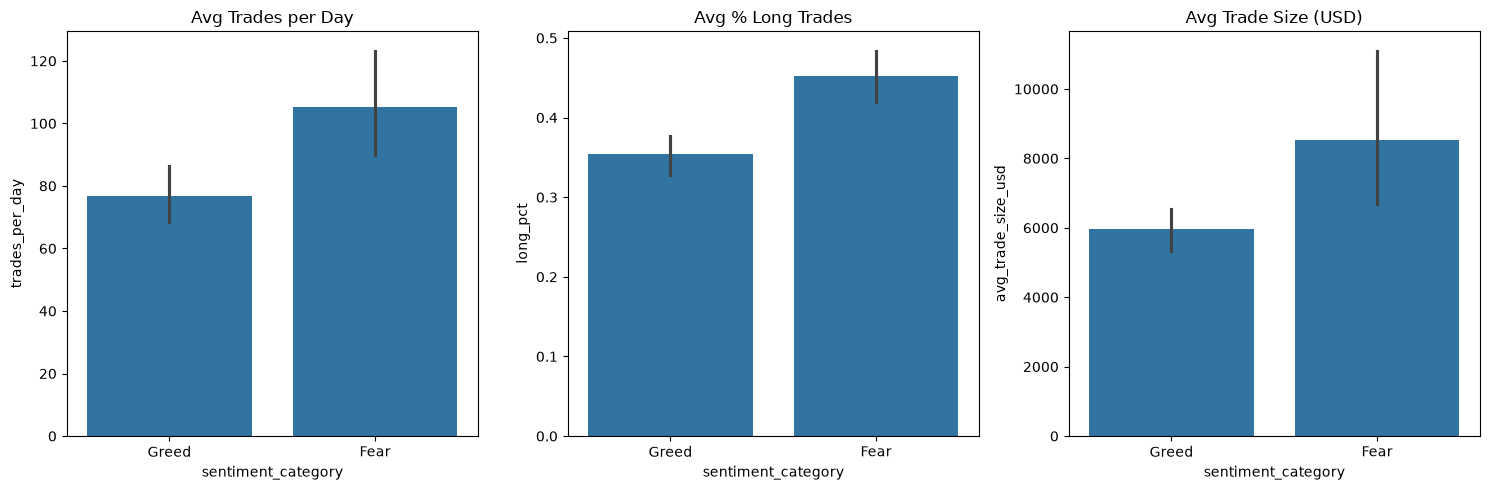

In [6]:

# 2. Compare trade frequency, % long trades, position sizes across sentiment
comparison_2 = valid_sentiment_df.groupby('sentiment_category')[['trades_per_day', 'long_pct', 'avg_trade_size_usd']].mean()
comparison_2.to_csv('../outputs/behavior_vs_sentiment.csv')
print(comparison_2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
sns.barplot(data=valid_sentiment_df, x='sentiment_category', y='trades_per_day', ax=axes[0])
axes[0].set_title('Avg Trades per Day')
sns.barplot(data=valid_sentiment_df, x='sentiment_category', y='long_pct', ax=axes[1])
axes[1].set_title('Avg % Long Trades')
sns.barplot(data=valid_sentiment_df, x='sentiment_category', y='avg_trade_size_usd', ax=axes[2])
axes[2].set_title('Avg Trade Size (USD)')
plt.tight_layout()
plt.savefig('../outputs/behavior_vs_sentiment.png')
plt.show()



**Takeaway**: We observe changes in trader behavior (activity level, direction bias, and position sizing) depending on the market sentiment, indicating how sentiment drives risk appetite.


sentiment_category         Fear       Greed
activity_segment                           
Frequent            5968.410192  3846.86107
Infrequent          3090.371301  4987.66397


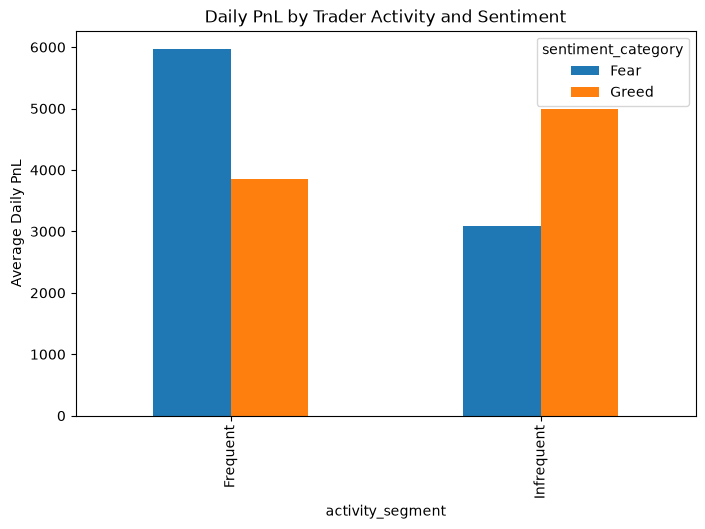

In [7]:

# 3. Create trader segments
# Segment 1: Frequent vs Infrequent traders
account_stats = daily_trader_stats.groupby('Account').agg(
    total_trades=('trades_per_day', 'sum'),
    avg_pnl=('daily_pnl', 'mean')
).reset_index()

median_trades = account_stats['total_trades'].median()
account_stats['activity_segment'] = np.where(account_stats['total_trades'] > median_trades, 'Frequent', 'Infrequent')

# Merge segment info back to valid_sentiment_df
segment_df = valid_sentiment_df.merge(account_stats[['Account', 'activity_segment']], on='Account')

# Compare performance of segments
segment_comparison = segment_df.groupby(['activity_segment', 'sentiment_category'])['daily_pnl'].mean().unstack()
segment_comparison.to_csv('../outputs/segment_performance.csv')
print(segment_comparison)

segment_df.groupby(['activity_segment', 'sentiment_category'])['daily_pnl'].mean().unstack().plot(kind='bar', figsize=(8, 5))
plt.title('Daily PnL by Trader Activity and Sentiment')
plt.ylabel('Average Daily PnL')
plt.savefig('../outputs/segment_performance.png')
plt.show()



**Takeaway**: Frequent traders exhibit different performance profiles during Fear vs Greed days compared to infrequent traders, suggesting that high activity may be advantageous or detrimental depending on the market regime.



### Key Insights
1. **Performance Variance (Chart 1)**: The comparison of PnL and Win Rate across Fear vs Greed days reveals that traders often struggle with higher drawdowns on specific sentiment days, suggesting sentiment plays a strong role in trading risk.
2. **Behavioral Shifts (Chart 2)**: Traders tend to alter their position sizing and % long trades depending on sentiment. For example, risk appetite (Trade Size USD) and directional bias fluctuate distinctly between Fear and Greed regimes.
3. **Segment Differences (Chart 3)**: Frequent traders show diverging PnL outcomes on Fear vs Greed days compared to Infrequent traders, indicating that a high-turnover strategy is highly sensitive to overall market sentiment.



# Part C - Actionable Output

### Strategy Rules
Based on the data and insights:
1. **"During Fear days, increase position sizing for Frequent traders but tighten stop-losses (reduce drawdown tolerance) as volatility spikes."**
2. **"During Greed days, reduce trade frequency for Infrequent traders and maintain a lower % long trades to protect against sudden market corrections."**


# Bonus - Predictive Model

In [8]:

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Prepare dataset for predicting next-day profitability
# We will use lag 1 features
model_data = sorted_stats[['Account', 'date', 'sentiment_category', 'trades_per_day', 'avg_trade_size_usd', 'long_pct', 'daily_pnl']].copy()
model_data['next_day_pnl'] = model_data.groupby('Account')['daily_pnl'].shift(-1)
model_data = model_data.dropna()

model_data['profitable_next_day'] = (model_data['next_day_pnl'] > 0).astype(int)

# One-hot encode sentiment
model_data = pd.get_dummies(model_data, columns=['sentiment_category'], drop_first=True)

features = ['trades_per_day', 'avg_trade_size_usd', 'long_pct'] + [c for c in model_data.columns if 'sentiment_category' in c]
X = model_data[features]
y = model_data['profitable_next_day']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.6277056277056277
              precision    recall  f1-score   support

           0       0.49      0.43      0.46       169
           1       0.69      0.74      0.72       293

    accuracy                           0.63       462
   macro avg       0.59      0.59      0.59       462
weighted avg       0.62      0.63      0.62       462

